# FraudGuard AI — Class Imbalance & Threshold Tuning

## Objective

Improve fraud detection performance by:

1. Applying class weighting to Logistic Regression.
2. Studying the precision-recall trade-off.
3. Evaluating different probability thresholds.
4. Comparing all experiments against the baseline model.

The primary goal is to improve fraud recall while maintaining acceptable
precision and false-positive levels.

## Threshold Tuning Results

Lowering the Logistic Regression decision threshold improved fraud detection
substantially.

At the default threshold of 0.50:

- True Positives: 56
- False Negatives: 39
- False Positives: 10
- Precision: 84.85%
- Recall: 58.95%
- F1 Score: 69.57%

At a threshold of 0.10:

- True Positives: 70
- False Negatives: 25
- False Positives: 13
- Precision: 84.34%
- Recall: 73.68%
- F1 Score: 78.65%

Among the evaluated thresholds, 0.10 provided the strongest trade-off. It
detected 14 additional fraudulent transactions while introducing only 3
additional false positives compared with the default threshold.

Class weighting increased recall further but generated a very large number
of false positives, making threshold tuning more suitable for the current
Logistic Regression experiment.

The 0.10 threshold is currently an experimental candidate rather than a
final production threshold. Final threshold selection should be performed
using validation data rather than the test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")

df = df.drop_duplicates().copy()

X = df.drop(columns=["Class"])
y = df["Class"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [5]:
y_train.value_counts()

Class
0    226602
1       378
Name: count, dtype: int64

In [6]:
weighted_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [7]:
weighted_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [10]:
y_pred_weighted = weighted_model.predict(X_test)


In [11]:
y_prob_weighted = weighted_model.predict_proba(X_test)[:, 1]

In [12]:
weighted_accuracy = accuracy_score(y_test, y_pred_weighted)
weighted_precision = precision_score(y_test, y_pred_weighted)
weighted_recall = recall_score(y_test, y_pred_weighted)
weighted_f1 = f1_score(y_test, y_pred_weighted)

weighted_roc_auc = roc_auc_score(
    y_test,
    y_prob_weighted
)

weighted_ap = average_precision_score(
    y_test,
    y_prob_weighted
)

In [13]:
print(f"Accuracy          : {weighted_accuracy:.4f}")
print(f"Precision         : {weighted_precision:.4f}")
print(f"Recall            : {weighted_recall:.4f}")
print(f"F1 Score          : {weighted_f1:.4f}")
print(f"ROC-AUC           : {weighted_roc_auc:.4f}")
print(f"Average Precision : {weighted_ap:.4f}")

Accuracy          : 0.9752
Precision         : 0.0562
Recall            : 0.8737
F1 Score          : 0.1057
ROC-AUC           : 0.9658
Average Precision : 0.6719


In [14]:
weighted_cm = confusion_matrix(
    y_test,
    y_pred_weighted
)

print(weighted_cm)

[[55258  1393]
 [   12    83]]


In [15]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)

baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

In [16]:
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

In [18]:
threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        baseline_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    cm = confusion_matrix(
        y_test,
        y_pred_threshold
    )

    tn, fp, fn, tp = cm.ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    })

In [19]:
threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1,False Positives,False Negatives,True Positives
0,0.5,0.848485,0.589474,0.695652,10,39,56
1,0.4,0.852941,0.610526,0.711656,10,37,58
2,0.3,0.845070,0.631579,0.722892,11,35,60
3,0.2,0.835443,0.694737,0.758621,13,29,66
4,0.1,0.843373,0.736842,0.786517,13,25,70


In [20]:
precision_values, recall_values, thresholds_pr = precision_recall_curve(
    y_test,
    baseline_prob
)

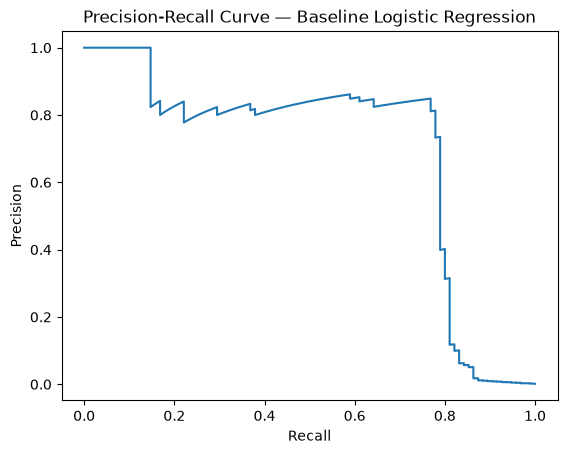

In [21]:
plt.plot(recall_values, precision_values)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline Logistic Regression")

plt.show()

In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Weighted Logistic Regression"
    ],

    "Precision": [
        0.8485,
        weighted_precision
    ],

    "Recall": [
        0.5895,
        weighted_recall
    ],

    "F1": [
        0.6957,
        weighted_f1
    ],

    "ROC-AUC": [
        0.9563448965921539,
        weighted_roc_auc
    ],

    "Average Precision": [
        0.6923283275024146,
        weighted_ap
    ]
})

comparison

,Model,Precision,Recall,F1,ROC-AUC,Average Precision
0,Baseline Logistic Regression,0.848500,0.589500,0.695700,0.956345,0.692328
1,Weighted Logistic Regression,0.056233,0.873684,0.105665,0.965839,0.671935
